El sistema no puede encontrar la ruta especificada.


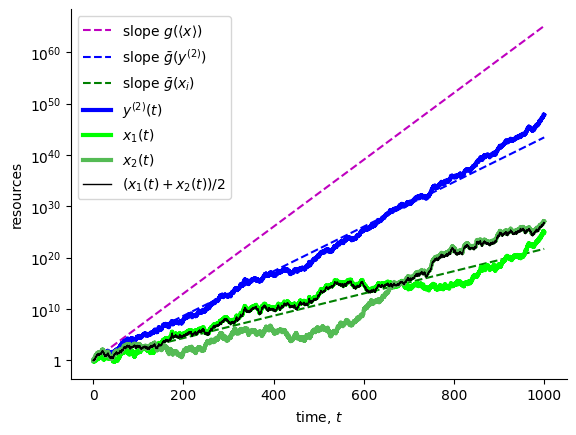

In [1]:
!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created 12 September 2019
Code to generate Fig.3 of Peters and Adamou 
"An evolutionary advantage of cooperation"
@author: Ole Peters
"""
import matplotlib.pyplot as plt
import numpy as np

# model parameters
mu=.15
sigma=np.sqrt(.2)
T = 10000
dt=.1
t=np.arange(0,(T+1)*dt,dt)
sdt=np.sqrt(dt)

#expectation value and time-average slopes
expectation=np.exp(mu*t)
t_growth_individual=np.exp((mu-sigma*sigma/2)*t)
t_growth_coop=np.exp((mu-sigma*sigma/4)*t)

# fix random seed for reproducibility
np.random.seed(11)

#Generate wealth of individual 1
noise_1=np.random.normal(loc=1+mu*dt, scale=sigma*sdt, size=T)
wealth_1=np.cumprod(noise_1)
wealth_1=np.insert(wealth_1,0,1)

#Generate wealth of individual 2
noise_2=np.random.normal(loc=1+mu*dt, scale=sigma*sdt, size=T)
wealth_2=np.cumprod(noise_2)
wealth_2=np.insert(wealth_2,0,1)

#Generate average wealth of individuals
wealth_ave=(wealth_1+wealth_2)/2

#Generate wealth of cooperating individuals
noise_co=(noise_1+noise_2)/2
wealth_co=np.cumprod(noise_co)
wealth_co=np.insert(wealth_co,0,1)

#Plotting
plt.plot(t,expectation,'m--',label=r'slope $g(\langle x \rangle)$')
plt.plot(t,t_growth_coop,'b--', label=r'slope $\bar{g}(y^{(2)})$')
plt.plot(t,t_growth_individual,'g--', label=r'slope $\bar{g}(x_i)$')

plt.plot(t,wealth_co,'b-',linewidth=3, label=r'$y^{(2)}(t)$')
plt.plot(t,wealth_1,color='#00ff00',linewidth=3, label=r'$x_1(t)$')
plt.plot(t,wealth_2,color='#55bb55',linewidth=3, label=r'$x_2(t)$')
plt.plot(t,wealth_ave,'k-',linewidth=1, label=r'$(x_1(t)+x_2(t))/2$')

plt.gca().spines['right'].set_color('none')
plt.gca().spines['top'].set_color('none')

plt.yscale('log')
plt.legend()
plt.xlabel('time, $t$')
plt.ylabel('resources')

plt.yticks([1,10.**10.,10.**20.,10.**30.,10.**40.,10.**50.,10.**60.],\
           ['1',r'$10^{10}$',r'$10^{20}$',r'$10^{30}$',\
            r'$10^{40}$',r'$10^{50}$',r'$10^{60}$'], rotation=0)

plt.savefig("./fig_trajectories.pdf", bbox_inches='tight')
plt.show()